## 01 — Data Audit | Multi-Disease Risk Profiler

## This notebook is the FIRST data-science step.
## Goal: understand and audit the raw dataset before cleaning,
## feature engineering, or machine-learning model training.

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## 1. Project paths

In [3]:

PROJECT_ROOT = Path.cwd()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / "README.md").exists() and (parent / "data").exists():
        PROJECT_ROOT = parent
        break

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Data Warehouse Multiclass.csv"

print("Python:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Python: /home/tonoy-sen/ds_env/bin/python
Project root: /home/tonoy-sen/Desktop/pro/MlProjects/multidisease-risk-profiler
Dataset: /home/tonoy-sen/Desktop/pro/MlProjects/multidisease-risk-profiler/data/raw/Data Warehouse Multiclass.csv
Dataset exists: True



## 2. Load raw dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Put the CSV inside data/raw/ or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())
display(df.sample(min(5, len(df)), random_state=42))

Rows: 280,985
Columns: 39


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,0.0,5.8,158.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,0.0,6.6,159.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,0.0,4.0,126.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,0.0,6.2,85.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,0.0,5.7,155.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
149558,Middle_Male_Overweight_Former_No,Middle,Male,Overweight,Former,No,43,0.471264,27.00,0.022265,0.005808,5.424782,154.0,224.000000,4.500000,237.000000,High,Yes,High,No,Yes,147.833988,Yes,Low,7.414141,12.534473,142.000000,118.000000,26.000000,10.800000,56.000000,63.000000,137.000000,Tertiary,Unemployed,hypertension,"0,0,1",HY,Abnormal
26305,Middle_Female_Overweight_Former_Yes,Middle,Female,Overweight,Former,Yes,28,0.298851,25.50,0.000000,0.000000,6.000000,126.0,225.000000,7.128587,148.024625,Low,Yes,Low,No,Yes,149.008407,Yes,Medium,7.582981,12.441519,134.911135,89.195931,15.126124,8.519058,74.377944,64.654176,128.631692,Primary,Unemployed,diabetes,"1,0,0",DI,Abnormal
158645,Young_Male_Obese_Current_No,Young,Male,Obese,Current,No,23,0.241379,39.80,0.036364,0.000000,5.707273,124.0,288.000000,4.100000,111.000000,Moderate,No,Low,No,Yes,149.333333,No,High,8.101519,13.468089,132.000000,78.000000,23.300000,10.100000,87.000000,90.000000,131.000000,Tertiary,Employed,hypertension,"0,0,1",HY,Abnormal
123260,Senior_Male_Obese_Former_No,Senior,Male,Obese,Former,No,70,0.781609,32.00,0.174475,0.214863,5.414701,139.0,269.000000,5.500000,138.000000,High,No,Medium,No,Yes,149.757035,Yes,Low,7.294863,12.657538,122.000000,99.000000,25.500000,13.600000,73.000000,56.000000,142.000000,Secondary,Unemployed,hypertension,"0,0,1",HY,Abnormal
83819,Young_Male_Normal_Never_No,Young,Male,Normal,Never,No,19,0.195402,20.87,0.000000,0.000000,6.000000,160.0,198.269231,6.578438,261.307692,High,No,High,No,No,149.846154,No,Medium,8.013048,11.845827,132.238854,88.353503,15.694586,8.830892,72.872611,65.187898,129.557325,Tertiary,Retired,diabetes,"0,0,0",N,Normal


## 3. Column names and data types

In [5]:
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[c].nunique(dropna=False) for c in df.columns],
    "missing_values": [df[c].isna().sum() for c in df.columns],
})
dtype_summary["missing_%"] = dtype_summary["missing_values"] / len(df) * 100
display(dtype_summary)


Column names:
01. composite_key
02. age_level
03. gender
04. bmi_level
05. smoking
06. diabetes
07. age
08. age_normalized
09. bmi
10. hypertension
11. heart_disease
12. HbA1c_level
13. glucose
14. cholesterol
15. sleep_hours
16. triglycerides
17. physical_activity
18. family_history
19. stress_level
20. low_hdl_cholesterol
21. high_ldl_cholesterol
22. blood_pressure
23. high_blood_pressure
24. sugar_consumption
25. crp_level
26. homocysteine_level
27. systolic_bp
28. diastolic_bp
29. alcohol_intake
30. salt_intake
31. heart_rate
32. hdl
33. ldl
34. education_level
35. employment_status
36. source_dataset
37. disease_flags
38. sublabel
39. label


,column,dtype,unique_values,missing_values,missing_%
0,composite_key,str,192,0,0.0
1,age_level,str,4,0,0.0
2,gender,str,2,0,0.0
3,bmi_level,str,4,0,0.0
4,smoking,str,3,0,0.0
5,diabetes,str,2,0,0.0
6,age,int64,88,0,0.0
7,age_normalized,float64,151,0,0.0
8,bmi,float64,14122,0,0.0
9,hypertension,float64,137,0,0.0


## 4. Missing values

In [6]:
missing = (
    df.isna().sum().to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

print("\nMissing-value audit:")
display(missing if not missing.empty else pd.DataFrame({"result": ["No missing values found"]}))



Missing-value audit:


,result
0,No missing values found


## 5. Duplicate audit

In [7]:
exact_duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicate_count:,}")
print(f"Duplicate percentage: {exact_duplicate_count / len(df) * 100:.4f}%")

Exact duplicate rows: 2,284
Duplicate percentage: 0.8129%



## 6. Cardinality

In [8]:
cardinality = pd.DataFrame({
    "column": df.columns,
    "unique_count": [df[c].nunique(dropna=False) for c in df.columns],
})
cardinality["unique_ratio_%"] = cardinality["unique_count"] / len(df) * 100
display(cardinality.sort_values("unique_count"))

,column,unique_count,unique_ratio_%
2,gender,2,0.000712
5,diabetes,2,0.000712
19,low_hdl_cholesterol,2,0.000712
17,family_history,2,0.000712
20,high_ldl_cholesterol,2,0.000712
22,high_blood_pressure,2,0.000712
38,label,2,0.000712
4,smoking,3,0.001068
16,physical_activity,3,0.001068
23,sugar_consumption,3,0.001068


## 7. Numerical summary

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns: {len(numeric_cols)}")
display(df[numeric_cols].describe().T)

Numerical columns: 20


,count,mean,std,min,25%,50%,75%,max
age,280985.0,49.665865,21.682350,2.000000,32.000000,50.000000,67.000000,89.000000
age_normalized,280985.0,0.547883,0.249222,0.000000,0.344827,0.551724,0.747126,1.000000
bmi,280985.0,27.490663,7.040373,10.010000,22.100000,27.320000,32.700000,95.690000
hypertension,280985.0,0.128218,0.187346,0.000000,0.000000,0.071429,0.217063,1.000000
heart_disease,280985.0,0.073390,0.138243,0.000000,0.000000,0.007299,0.115053,1.000000
HbA1c_level,280985.0,5.947475,0.954072,3.500000,5.384805,5.800000,6.865766,9.000000
glucose,280985.0,135.258646,38.477865,70.000000,100.000000,138.000000,160.000000,300.000000
cholesterol,280985.0,224.045525,35.525530,150.000000,202.000000,225.000000,243.000000,300.000000
sleep_hours,280985.0,6.954652,1.426412,4.000000,6.200000,6.975185,7.700000,10.000000
triglycerides,280985.0,178.995744,67.336085,50.000000,129.000000,179.000000,242.000000,400.000000


## 8. Categorical summary

In [10]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
display(pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [df[c].nunique(dropna=False) for c in categorical_cols]
}).sort_values("unique_count"))

/tmp/ipykernel_15522/83611094.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Categorical columns: 19


,column,unique_count
2,gender,2
5,diabetes,2
7,family_history,2
9,low_hdl_cholesterol,2
10,high_ldl_cholesterol,2
11,high_blood_pressure,2
18,label,2
6,physical_activity,3
12,sugar_consumption,3
13,education_level,3


## 9. Categorical distributions

In [15]:
for col in categorical_cols:
    print(f"\n\n{col}\n")
    counts = df[col].value_counts(dropna=False).head(20)
    display(pd.DataFrame({
        "count": counts,
        "percent": counts / len(df) * 100
    }))



composite_key



,count,percent
composite_key,,
Middle_Female_Overweight_Never_No,6097,2.169867
Mature_Female_Overweight_Never_No,5778,2.056338
Middle_Female_Obese_Never_No,5020,1.786572
Mature_Female_Obese_Never_No,4986,1.774472
Middle_Female_Normal_Never_No,4806,1.710412
Middle_Male_Overweight_Never_No,4691,1.669484
Mature_Male_Overweight_Never_No,4616,1.642792
Young_Female_Normal_Never_No,3835,1.364842
Mature_Male_Obese_Never_No,3716,1.322491




age_level



,count,percent
age_level,,
Mature,87632,31.187430
Middle,85344,30.373152
Senior,70225,24.992437
Young,37784,13.446981




gender



...

,count,percent
disease_flags,,
"0,0,0",106884,38.039041
"0,0,1",69806,24.843319
"1,0,1",66473,23.657135
"1,0,0",31918,11.359325
"0,1,0",2595,0.923537
"1,1,0",1398,0.497535
"0,1,1",1066,0.379380
"1,1,1",845,0.300728




sublabel



,count,percent
sublabel,,
N,106884,38.039041
HY,69806,24.843319
DI_HY,66473,23.657135
DI,31918,11.359325
HT,2595,0.923537
DI_HT,1398,0.497535
HT_HY,1066,0.379380
DI_HT_HY,845,0.300728




label



,count,percent
label,,
Abnormal,174101,61.960959
Normal,106884,38.039041


## 10. Important project columns

In [19]:
important_columns = [
    "diabetes", "hypertension", "heart_disease", "bmi", "bmi_level",
    "disease_flags", "sublabel", "label", "source_dataset", "composite_key"
]

available = [c for c in important_columns if c in df.columns]
not_found = [c for c in important_columns if c not in df.columns]

print("\nImportant columns found:", available)
if not_found:
    print("Important columns not found:", not_found)

for col in available:
    print(f"\n\n{col}\n{'_' * 70}\n")
    print("dtype:", df[col].dtype)
    print("unique:", df[col].nunique(dropna=False))
    display(df[col].value_counts(dropna=False).head(30).to_frame("count"))



Important columns found: ['diabetes', 'hypertension', 'heart_disease', 'bmi', 'bmi_level', 'disease_flags', 'sublabel', 'label', 'source_dataset', 'composite_key']


diabetes
______________________________________________________________________

dtype: str
unique: 2


,count
diabetes,
No,180351
Yes,100634




hypertension
______________________________________________________________________

dtype: float64
unique: 137


,count
hypertension,
0.000000,106307
1.000000,8081
0.333333,3597
0.142857,3215
0.217391,3141
0.166667,2519
0.200000,2319
0.111111,2296
0.057722,2061




heart_disease
______________________________________________________________________

dtype: float64
unique: 125


...

,count
label,
Abnormal,174101
Normal,106884




source_dataset
______________________________________________________________________

dtype: str
unique: 3


,count
source_dataset,
hypertension,174982
diabetes,96128
heart,9875




composite_key
______________________________________________________________________

dtype: str
unique: 192


,count
composite_key,
Middle_Female_Overweight_Never_No,6097
Mature_Female_Overweight_Never_No,5778
Middle_Female_Obese_Never_No,5020
Mature_Female_Obese_Never_No,4986
Middle_Female_Normal_Never_No,4806
Middle_Male_Overweight_Never_No,4691
Mature_Male_Overweight_Never_No,4616
Young_Female_Normal_Never_No,3835
Mature_Male_Obese_Never_No,3716


# 11. Potential identifiers / metadata

In [20]:
possible_id_cols = [
    c for c in ["id", "patient_id", "composite_key", "source_dataset",
                "index", "Unnamed: 0"] if c in df.columns
]

print("\nPotential identifier / metadata columns:")
for col in possible_id_cols:
    print(f"- {col}: {df[col].nunique(dropna=False):,} unique values")


Potential identifier / metadata columns:
- composite_key: 192 unique values
- source_dataset: 3 unique values


## 12. Correlation inspection

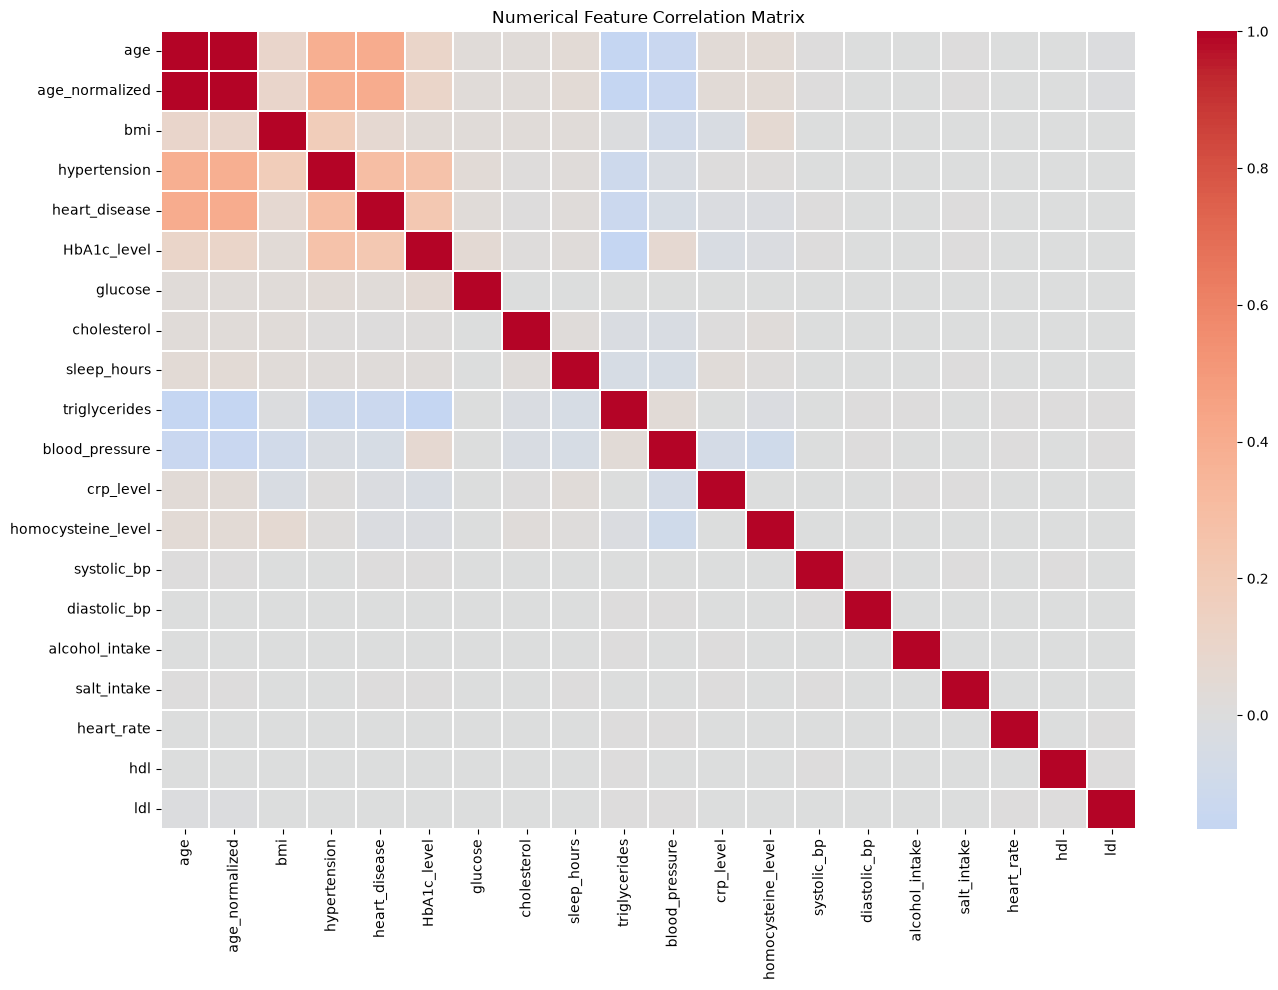

In [21]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
    plt.title("Numerical Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

## 13. Leakage screening — investigation only, not automatic removal

In [22]:
candidate_targets = [
    c for c in ["diabetes", "hypertension", "heart_disease", "bmi_level",
                "disease_flags", "sublabel", "label"] if c in df.columns
]

print("\nCandidate target / label-related columns:")
print(candidate_targets)

print("\nColumns requiring leakage investigation:")
for col in ["disease_flags", "sublabel", "label", "source_dataset", "bmi_level"]:
    if col in df.columns:
        print(f"- {col}")


Candidate target / label-related columns:
['diabetes', 'hypertension', 'heart_disease', 'bmi_level', 'disease_flags', 'sublabel', 'label']

Columns requiring leakage investigation:
- disease_flags
- sublabel
- label
- source_dataset
- bmi_level


## 14. Final audit summary

In [26]:

print("DATA AUDIT SUMMARY")
print("_" * 80 +"\n")
print(f"Rows:                 {len(df):,}")
print(f"Columns:              {df.shape[1]}")
print(f"Numerical columns:    {len(numeric_cols)}")
print(f"Categorical columns:  {len(categorical_cols)}")
print(f"Missing cells:        {int(df.isna().sum().sum()):,}")
print(f"Exact duplicate rows: {exact_duplicate_count:,}")
if "composite_key" in df.columns:
    print(f"Composite-key unique: {df['composite_key'].nunique(dropna=False):,}")

print("\nCandidate targets:", candidate_targets)


DATA AUDIT SUMMARY
________________________________________________________________________________

Rows:                 280,985
Columns:              39
Numerical columns:    20
Categorical columns:  19
Missing cells:        0
Exact duplicate rows: 2,284
Composite-key unique: 192

Candidate targets: ['diabetes', 'hypertension', 'heart_disease', 'bmi_level', 'disease_flags', 'sublabel', 'label']
